In [59]:
using Pkg
Pkg.activate(ENV["PYTHON_JULIAPKG_PROJECT"])
using ReactionMechanismSimulator

  Activating project at `~/miniforge3/envs/rmg_electrocat_2/julia_env`


In [60]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK

In [61]:
outdict = readinput("Ag_C2_042925.rms")

[14:30:43] WARNING: not removing hydrogen atom without neighbors
[14:30:43] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-Electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-Electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-Electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-Electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-Electrocat/ReactionMechanismSimulator.j

Dict{Any, Any} with 4 entries:
  "Solvents"              => Solvent[Solvent("water", RiedelViscosity{Float64}(…
  Set(["gas", "surface"]) => Dict{Any, Any}("Reactions"=>ElementaryReaction[pro…
  "gas"                   => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…
  "surface"               => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…

In [62]:
boundarylayerspcs = outdict["gas"]["Species"]
boundarylayerrxns = outdict["gas"]["Reactions"]
surfspcs = outdict["surface"]["Species"]
surfrxns = outdict["surface"]["Reactions"]
interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
solv = outdict["Solvents"][1];

In [63]:
sitedensity = 2.294e-5; # Ag111 site density is 2.294e-9 mol/cm^2 or 2.294e-5 mol/m^2
boundarylayer = IdealDiluteSolution(boundarylayerspcs,boundarylayerrxns,solv,name="boundarylayeruid",diffusionlimited=true);
surf = IdealSurface(surfspcs,surfrxns,sitedensity,name="surface");

In [64]:
# Reservoir is a 100 mL (100e-6 m^3) cell
# Proton concentration is 10^-7 mol/L (10^-4 mol/m^3)
# CO2 concentration is 0.01 mol/L (10 mol/m^3), saturation solubility ~0.03 mol/L
# AVratio in experiments is 36 m^-1 but is measured by surface area/reservoir volume
# Area of the electrode is therefore 3.6e1 m^-1 * 1e2 * 1e-6 m^3 = 3.6e-3 m^2 = 36 cm^2
# Assume boundary layer thickness d_bl = 1 mm or 1e-3 m
# Volume of the boundary layer V_bl = 3.6e-3 m^2 * 1e-3 m = 3.6e-6 m^3
# Actual AVratio is therefore 3.6e-3 m^2 / 3.6e-6 m^3 = 1e3 m^-1 (reciprocal of d_bl)
# Amount of sites is 2.943e-5 mol/m^2 * 3.6e-3 m^2 = 10.595e-8 mol

# For earlier simulations, a 100x linear scale factor is applied,
# so volume becomes 100e-6 m^3 * (1e2)^3 = 100 m^3,
# electrode area becomes 3.6e-3 * (1e2) ^2 = 3.6e1 m^2,
# AVratio becomes 3.6e1 m^2 / 1e2 m^3 = 0.36 m^-1
# Volume of the boundary layer becomes 3.6e1 m^2 * 1e-3 m = 3.6e-2 m^3

C_proton = 1e-7*1e3;
C_co2 = 1e-2*1e3;
C_default = 1e-12;
V_res = 1e3;
layer_thickness = 1e-3;
AVratio = 36;
A_surf = V_res*AVratio;
V_bl = A_surf*layer_thickness;
# V_bl = V_res;
sites = sitedensity*A_surf;

# The initial conditions for individual species are moles not concentration, so we need to multiply concentration by boundary layer volume
initialcondsboundarylayer = Dict(["proton"=>C_proton*V_bl,
                                  "CO2"=>C_co2*V_bl,
                                #   "H2"=>C_default*10*V_bl,
                                #   "O=CO"=>C_default*V_bl,
                                  "V"=>V_bl,"T"=>300,"Phi"=>0.0,"d"=>0.0]);
initialcondsreservoir = Dict(["proton"=>C_proton,
                              "CO2"=>C_co2,
                              "V"=>V_res,"T"=>300]);


# Assume voltage is -1.0 V vs. R.H.E. which equates to -1.414 V vs. S.H.E. at pH=7
initialcondssurf = Dict(["CO2X"=>0.4*sites,
        # "CHO2X"=>0.1*sites,
        # "CO2HX"=>0.1*sites,
        # "OX"=>0.1*sites,
        # "OCX"=>0.1*sites,
        "vacantX"=>0.6*sites,
        # "CH2O2X"=>0.05*sites,
        # "CHOX"=>0.04*sites,
        # "CH2OX"=>0.01*sites,
        "A"=>A_surf,"T"=>300,"Phi"=>-1.414]);

In [65]:
domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(phase=boundarylayer, initialconds=initialcondsboundarylayer);
domaincat,y0cat,pcat = ConstantTAPhiDomain(phase=surf,
    initialconds=initialcondssurf);

In [66]:
# Set proton diffusivity to a higher value than calculated from Stokes Einstein equation
# The values are taken from DOI: 10.1039/C8SC01253A
# Values calculated from MD is 1.015 A^2/ps, experimental values are 0.932 A^2/ps.
# 1 A^2/ps = 1e-8 m^2/s
domainboundarylayer.diffusivity[6] = 0.932e-8

9.32e-9

In [67]:
inter,pinter = ReactiveInternalInterfaceConstantTPhi(domainboundarylayer,
  domaincat,interfacerxns,298.15,A_surf);

In [68]:
# start with 1mm layer thickness
diffusionlayer = ConstantReservoirDiffusion(domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness);

In [69]:
interfaces = [inter, diffusionlayer];

In [70]:
@time react,y0,p = Reactor((domainboundarylayer,domaincat), (y0boundarylayer,y0cat), (0.0, 1e3), interfaces, (pboundarylayer,pcat,pinter));

  0.003796 seconds (8.47 k allocations: 7.894 MiB)


In [71]:
@time sol = solve(react.ode,Sundials.CVODE_BDF(),abstol=1e-22,reltol=1e-8);
println(sol.t[end]);
println(sol.retcode);

  0.148496 seconds (275.89 k allocations: 196.480 MiB, 4.38% gc time)
1000.0
Success


In [72]:
ssys = SystemSimulation(sol,(domainboundarylayer,domaincat,), interfaces,p);

In [73]:
"""
diffusive flux to the reservoir
"""
function flux_to_reservoir(sim,t,reservoirinterface)
    cs = concentrations(sim,t)
    return reservoirinterface.A .* sim.domain.diffusivity .* (cs - reservoirinterface.c) / reservoirinterface.layer_thickness
end

"""
Integrates the flux to the reservoir and computes the concentration assuming
there is no prior concentration of that species in the reservoir
"""
function get_reservoir_concentration(sim,t,reservoirinterface,Vres,C0)
    intg,err = quadgk(x -> flux_to_reservoir(sim,x,reservoirinterface), 0, t);
    intg[5] = 0;
    intg[6] = 0;
    return C0 + intg./Vres
end

get_reservoir_concentration

In [74]:
# Logarithmic time scale
t_vals = 10 .^ range(-12, stop=3, length=160);

# Compute reservoir concentrations
flux_vals = [flux_to_reservoir(ssys.sims[1], t, diffusionlayer) for t in t_vals]

conc_vals_bl = [concentrations(ssys.sims[1], t) for t in t_vals]
flux_matrix = hcat(flux_vals...);
conc_matrix_bl = hcat(conc_vals_bl...);


In [75]:
conc_0 = concentrations(ssys.sims[1], 0)
t_vals_2 = 10 .^ range(-9, stop=3, length=130);
conc_vals = [get_reservoir_concentration(ssys.sims[1], t, diffusionlayer, V_res, conc_0) for t in t_vals_2]
conc_matrix = hcat(conc_vals...);

In [76]:
function plotC_Reservoir(sim, cs, tvals, tol, exclude)
    clf()
    xs = cs
    maxes = maximum(xs, dims=2)

    time_filtered = tvals
    xs_filtered = xs

    # Custom species order and their corresponding names and color
    species_order = ["CO2", "proton", "H2", "O=CO", "C=O", "CO-2", "CCO", "CH4", "OCO", "COC", "COCO", "CC(=O)O", "COC=O"]
    color_map = Dict("CO2" => "black", "proton" => "grey", "H2" => "green",
                        "O=CO" => "red", "C=O" => "brown", "CO-2" => "blue", "CCO" => "magenta",
                        "CH4" => "brown", "OCO" => "orange", "COC" => "teal", "COCO" => "lime", "CC(=O)O" => "teal", "COC=O" => "lime")
    # Replacement map for species labels
    replacement_map = Dict("CO-2" => "CH3OH", "O=CO" => "HCOOH", "C=O" => "HCHO",
                            "CCO" => "C2H5OH", "OCO" => "CH2(OH)2", "COC" => "CH3OCH3", "COCO" => "CH3OCH2OH", "CC(=O)O" => "CH3COOH", "COC=O" => "CH3OCHO")

    # Build a map of species names to indices
    name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    # Keep track of whether the species is plotted, used for later checks
    plotted = falses(length(sim.domain.phase.species))

    # Plot species from the custom species dictionary
    for species_name in species_order
        if species_name in exclude
            continue
        end

        if haskey(name_to_index, species_name)
            i = name_to_index[species_name]

            if (maxes[i] > tol) || (species_name == "proton") || (species_name == "CCO")  # Always plot proton and ethanol
                plot_label = get(replacement_map, species_name, species_name)
                plot_color = color_map[species_name]

                plot(time_filtered, xs_filtered[i, :]/1000, label=plot_label, color=plot_color)
                plotted[i] = true  # Mark as plotted
            end
        end
    end

    # Plot any remaining species that passed tolerance but were not in species_order
    for i in 1:length(sim.domain.phase.species)
        if plotted[i] || sim.domain.phase.species[i].name in exclude
            continue
        end

        if maxes[i] > tol
            species_name = sim.domain.phase.species[i].name
            plot(time_filtered, xs_filtered[i, :]/1000, label=species_name)  # Default color
        end
    end

    xlabel("Time (s)", fontsize=14)
    ylabel("Bulk Concentration (mol/L)", fontsize=14)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
end

plotC_Reservoir (generic function with 1 method)

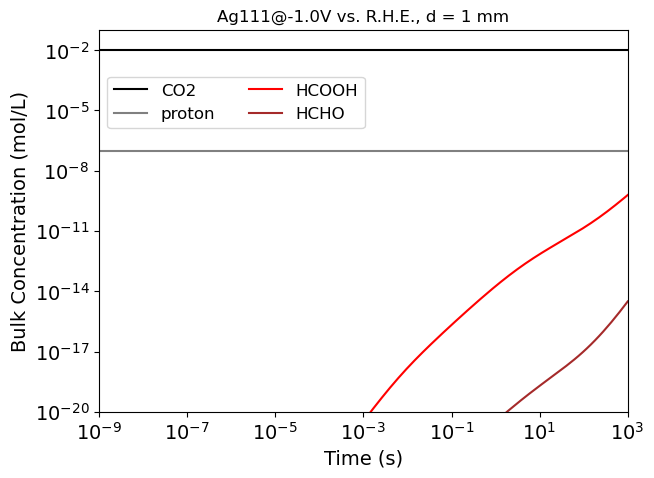

In [77]:
exclude_species = ["H2O", "O=CC=O", "O=CCO", "CC=O"]
plotC_Reservoir(ssys.sims[1], conc_matrix, t_vals_2, 1e-12, exclude_species)

xscale("log")
yscale("log")
xlim(1e-9, 1e3)
ylim(1e-20, 1e-1)
legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
title("Ag111@-1.0V vs. R.H.E., d = 1 mm")
gcf()

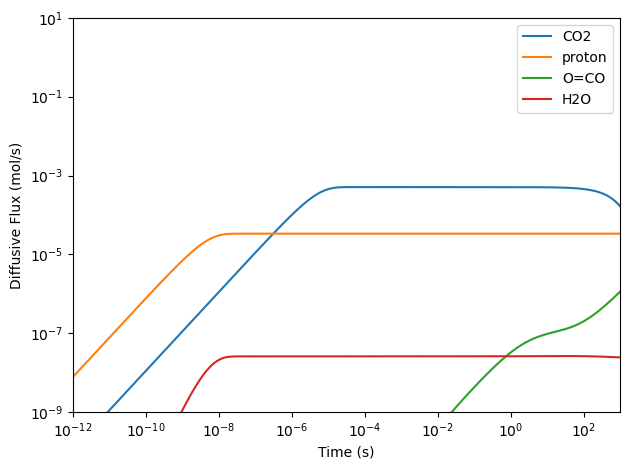

In [78]:
clf()

for i in 1:size(flux_matrix, 1)
    if maximum(abs.(flux_matrix[i, :])) > 1e-10
        plot(t_vals, abs.(flux_matrix[i, :]), label=ssys.sims[1].domain.phase.species[i].name)

    end
end

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Diffusive Flux (mol/s)")
xlim(1e-12, 1e3)
ylim(1e-9, 1e1)
legend()
tight_layout()
gcf()

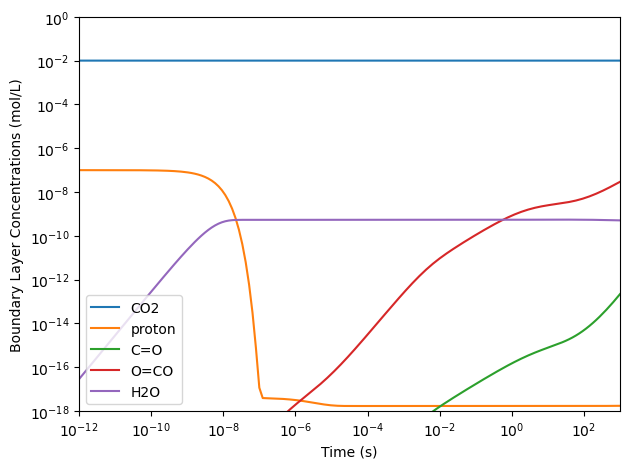

In [79]:
clf()
for i in 1:size(conc_matrix_bl, 1)
    if maximum(conc_matrix_bl[i, :]) > 1e-10
        plot(t_vals, conc_matrix_bl[i, :]/1e3, label=ssys.sims[1].domain.phase.species[i].name)

    end
end

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Boundary Layer Concentrations (mol/L)")
xlim(1e-12, 1e3)
ylim(1e-18, 1)
legend()
tight_layout()
gcf()

In [80]:
# Helper function
function plotX(sim, tol, t_end, exclude)
    clf()
    xs = molefractions(sim)
    maxes = maximum(xs, dims=2)

    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]

    for i = 1:length(maxes)
        species_name = sim.domain.phase.species[i].name
        if maxes[i] > tol && !(species_name in exclude)
            plot(time_filtered, xs_filtered[i,:], label=species_name)
        end
    end
    legend()
    xlabel("Time (s)")
    ylabel("Concentration (mol/m^3)")
end

plotX (generic function with 1 method)

In [81]:
function plotC(sim, tol, t_end, exclude)
    clf()
    xs = concentrations(sim)
    maxes = maximum(xs, dims=2)

    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]

    # Custom species order and their corresponding names and color
    species_order = ["CO2", "proton", "H2", "O=CO", "C=O", "CO-2", "CCO", "CH4", "OCO", "COC", "COCO", "CC(=O)O", "COC=O"]
    color_map = Dict("CO2" => "black", "proton" => "grey", "H2" => "green",
                        "O=CO" => "red", "C=O" => "brown", "CO-2" => "blue", "CCO" => "magenta",
                        "CH4" => "brown", "OCO" => "orange", "COC" => "teal", "COCO" => "lime", "CC(=O)O" => "teal", "COC=O" => "lime")
    # Replacement map for species labels
    replacement_map = Dict("CO-2" => "CH3OH", "O=CO" => "HCOOH", "C=O" => "HCHO",
                            "CCO" => "C2H5OH", "OCO" => "CH2(OH)2", "COC" => "CH3OCH3", "COCO" => "CH3OCH2OH", "CC(=O)O" => "CH3COOH", "COC=O" => "CH3OCHO")

    # Build a map of species names to indices
    name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    # Keep track of whether the species is plotted, used for later checks
    plotted = falses(length(sim.domain.phase.species))

    # Plot species from the custom species dictionary
    for species_name in species_order
        if species_name in exclude
            continue
        end

        if haskey(name_to_index, species_name)
            i = name_to_index[species_name]

            if (maxes[i] > tol) || (species_name == "proton") || (species_name == "CCO")  # Always plot proton and ethanol
                plot_label = get(replacement_map, species_name, species_name)
                plot_color = color_map[species_name]

                plot(time_filtered, xs_filtered[i, :]/1000, label=plot_label, color=plot_color)
                plotted[i] = true  # Mark as plotted
            end
        end
    end

    # Plot any remaining species that passed tolerance but were not in species_order
    for i in 1:length(sim.domain.phase.species)
        if plotted[i] || sim.domain.phase.species[i].name in exclude
            continue
        end

        if maxes[i] > tol
            species_name = sim.domain.phase.species[i].name
            plot(time_filtered, xs_filtered[i, :]/1000, label=species_name)  # Default color
        end
    end

    xlabel("Time (s)", fontsize=14)
    ylabel("Boundary Layer Concentration (mol/L)", fontsize=14)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
end

plotC (generic function with 1 method)

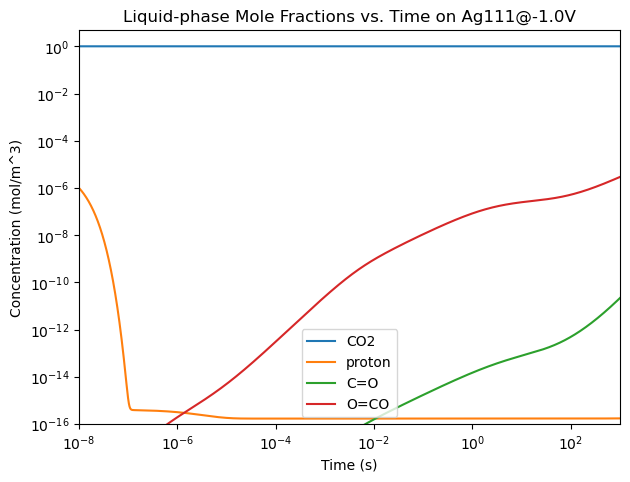

In [82]:
exclude_species = ["H2O"]
plotX(ssys.sims[1], 1e-12, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-8, 1e3)
ylim(1e-16, 5)
title("Liquid-phase Mole Fractions vs. Time on Ag111@-1.0V")
gcf()

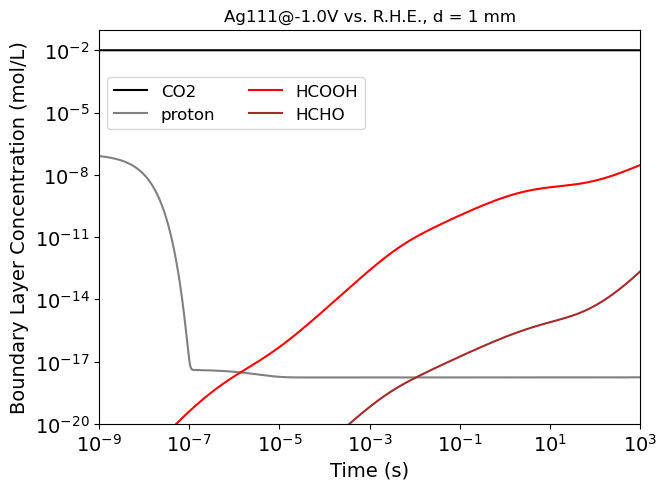

In [83]:
exclude_species = ["H2O", "O=CC=O", "O=CCO", "CC=O"]
plotC(ssys.sims[1], 1e-10, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-9, 1e3)
ylim(1e-20, 1e-1)
title("Ag111@-1.0V vs. R.H.E., d = 1 mm")
gcf()

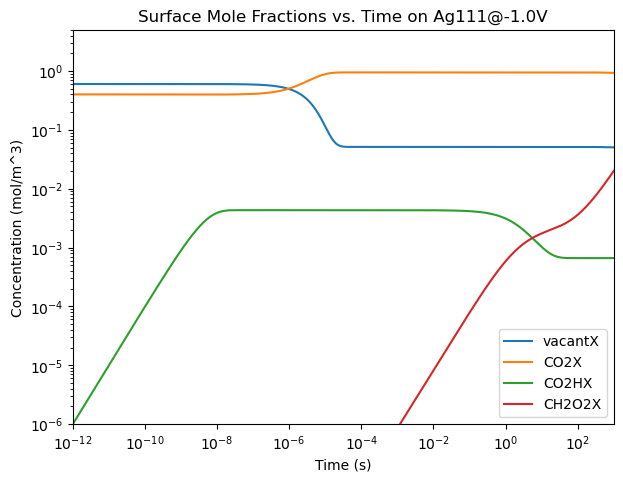

In [84]:
exclude_species = ["H2O"]
plotX(ssys.sims[2], 1e-3, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-6, 5)
title("Surface Mole Fractions vs. Time on Ag111@-1.0V")
gcf()

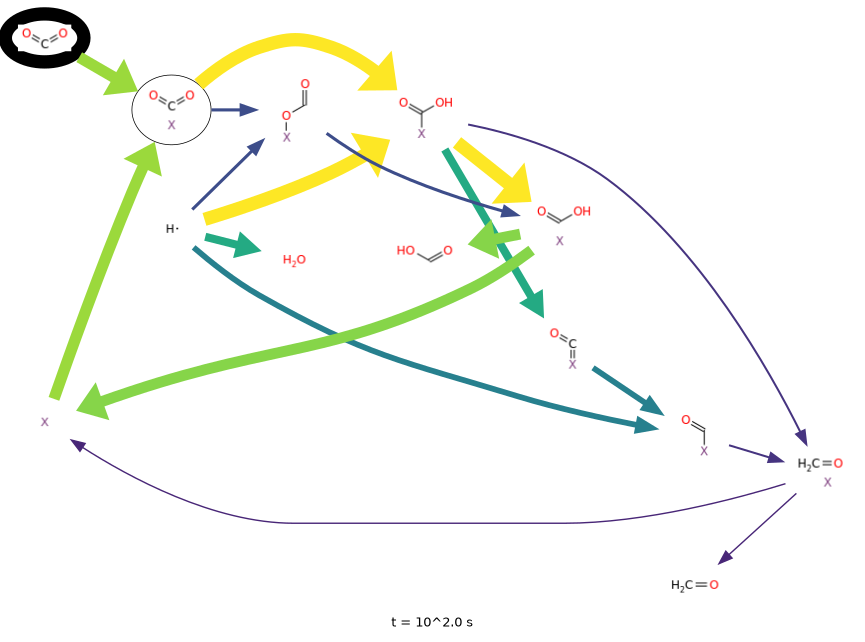

In [131]:
fd = getfluxdiagram(ssys,1e2;speciesratetolerance=1e-8)

In [132]:
ts = 10.0 .^ range(-10, 3; step=1)
fd1 = makefluxdiagrams(ssys, ts)

BoundsError: BoundsError: attempt to access 1414-element Vector{Float64} at index [6, 2]

In [115]:
fieldnames(typeof(ssys))

(:sol, :sims, :interfaces, :names, :species, :reactions, :p)

CHO2X+CHO2X<=>CO2X+CH2O2X

In [147]:
species_list = ["CO2", "CO2X", "CO2HX", "CH2O2X", "O=CO"];
spc_names = [s.name for s in ssys.species];
G_val = Float64[];
T = 300.0;

for spc in species_list
    ind = findfirst(==(spc), spc_names);
    if isnothing(ind)
        @warn "Species $spc not found"
        push!(G_val, NaN);
    else
        sp = ssys.species[ind];
        G = getGibbs(sp.thermo, T);
        push!(G_val, G);
    end
end

In [156]:
dG = G_val .- G_val[1];

clf()
for (i, name) in enumerate(species_list)
    hline([dG[i]], label=name, linewidth=2)
end
gcf()

UndefVarError: UndefVarError: `hline` not defined

In [86]:
function plotROP(ssys,name,t;N=0,tol=0.01)
    clf()
    rop = rops(ssys, name, t)
    inds = rop.nzind[reverse(sortperm(abs.(rop.nzval)))]
    if N == 0
        N = length(inds)
    elseif N > length(inds)
        N = length(inds)
    end
    inds = inds[1:N]
    mval = abs(rop[inds[1]])
    minval = mval*tol
    k = 1
    while k < length(inds) && abs(rop[inds[k]]) >= minval
        k += 1
    end
    inds = inds[1:k]
    net_rops = sum(rop[inds])
    println("Net ROPs for species $name is: $net_rops")

    for (i, j) in enumerate(inds)
        println("Showing the reaction with $i th highest ROP for species $name:")
        println(getrxnstr(ssys.reactions[j]))
        println("ROP = ", rop[inds[i]])
        println(ssys.reactions[j].kinetics)
    end

    xs = Array{Float64,1}(1:length(inds))
    barh(xs,reverse(rop[inds]))
    yticks(xs,reverse(getrxnstr.(ssys.reactions[inds])))
    xlabel("Production/Loss Rate mol/s")
    gcf()
end

plotROP (generic function with 1 method)

In [87]:
function PrintKinDetail(inter, speciesname)
    println("Showing Kinetics details for reactions involving species $speciesname\n")
    for (i,rxn) in enumerate(inter.reactions)
        flag = false
        for j = 1:length(rxn.reactants)
            if rxn.reactants[j].name == speciesname
                flag = true
            end
        end
        for j = 1:length(rxn.products)
            if rxn.products[j].name == speciesname
                flag = true
            end
        end
        if flag
            println(getrxnstr(rxn))
            println(rxn.kinetics)
            kf = inter.kfs[i]
            krev = inter.krevs[i]
            kc = kf/krev
            println("kf = $kf")
            println("krev = $krev")
            println("Kc = $kc\n")
        end
    end
end

PrintKinDetail (generic function with 1 method)

In [88]:
"""
Integrates the ROP in the boundary layer and computes the concentration
"""
function get_boundary_layer_concentration(sim,t,spc,Vbl,C_0)
    intg,err = quadgk(x -> sum(rops(sim,spc,t)), 0, t);
    return C_0 + intg ./ Vbl;
end

get_boundary_layer_concentration

In [89]:
"""
diffusive flux to the reservoir using concentration from ROP integration
"""
function flux_to_reservoir_2(bsol,t,spc,Vbl,C_0,reservoirinterface)
    cs = get_boundary_layer_concentration(bsol,t,spc,Vbl,C_0)
    spc_idx = findfirst(s -> s.name == spc, bsol.sims[1].species)
    d = bsol.sims[1].domain.diffusivity[spc_idx];
    c_res = reservoirinterface.c[spc_idx];
    # println(reservoirinterface.A);
    # println(reservoirinterface.layer_thickness);
    # println(sim.domain.diffusivity);
    # println(cs);
    # println(reservoirinterface.c);
    return reservoirinterface.A * d * (cs - c_res) / reservoirinterface.layer_thickness
end

flux_to_reservoir_2

In [90]:
# Compute ROP over time
ROP_vals = [sum(rops(ssys, "O=CO", t)) for t in t_vals];
# Compute boundary layer accumulation by integration
Cbl_vals = [get_boundary_layer_concentration(ssys, t, "O=CO", V_bl, C_default) for t in t_vals];
# Compute flux over time using Cbl_vals
F_vals = [flux_to_reservoir_2(ssys, t, "O=CO", V_bl, C_default, diffusionlayer) for t in t_vals];

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


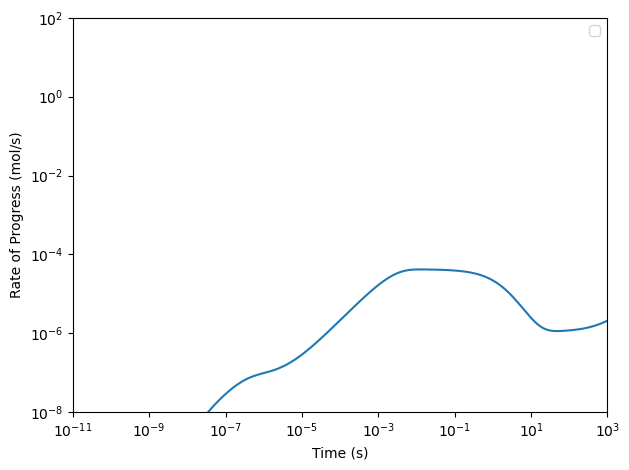

In [91]:
# Plots the ROP of O=CO
clf()

plot(t_vals, ROP_vals)

xscale("log")
xlim(1e-11,1e3)
yscale("log")
ylim(1e-8,1e2)
xlabel("Time (s)")
ylabel("Rate of Progress (mol/s)")
legend()
tight_layout()
gcf()

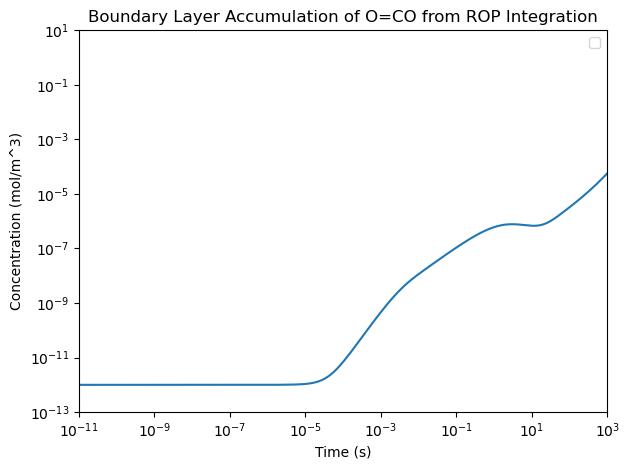

In [92]:
# Plots the Boundary Layer Concentration of O=CO from ROP Integration WITHOUT Diffusion Flux Into Reservoir
clf()

plot(t_vals, Cbl_vals)

xscale("log")
xlim(1e-11,1e3)
yscale("log")
ylim(1e-13,1e1)
xlabel("Time (s)")
ylabel("Concentration (mol/m^3)")
title("Boundary Layer Accumulation of O=CO from ROP Integration")
legend()
tight_layout()
gcf()

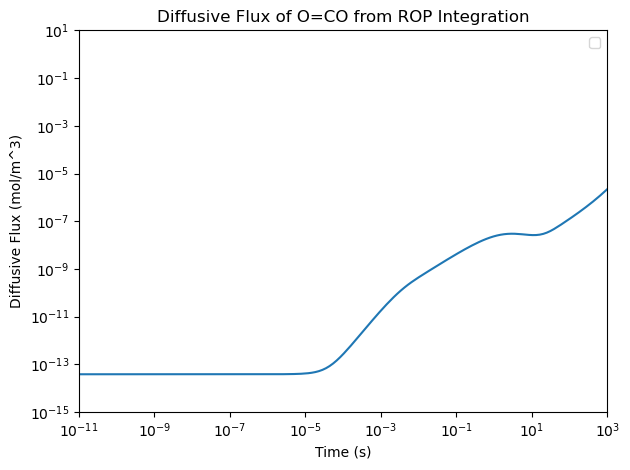

In [93]:
# Plots the Diffusive Flux of O=CO using ROP Integration
clf()

plot(t_vals, F_vals)

xscale("log")
xlim(1e-11,1e3)
yscale("log")
ylim(1e-15,1e1)
xlabel("Time (s)")
ylabel("Diffusive Flux (mol/m^3)")
title("Diffusive Flux of O=CO from ROP Integration")
legend()
tight_layout()
gcf()

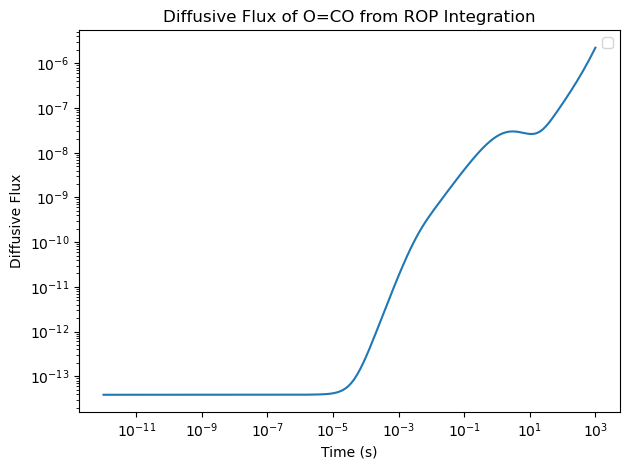

In [94]:
# Plots the Diffusion Flux Into Reservoir Using Integrated Concentration from ROP Analysis
clf()

plot(t_vals, F_vals)

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Diffusive Flux")
title("Diffusive Flux of O=CO from ROP Integration")
legend()
tight_layout()
gcf()

Net ROPs for species proton is: -3.355199999941229e-5
Showing the reaction with 1 th highest ROP for species proton:
proton+CO2X<=>CO2HX
ROP = -3.3526266453156255e-5
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 72363.75
  q: Float64 0.62
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species proton:
proton+CO2HX<=>H2O+OCX
ROP = -2.386524368354331e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 24121.25
  q: Float64 0.36
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species proton:
proton+OCX<=>CHOX
ROP = -1.8431611907427894e-9
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 43418.25
  q: Float64 0.49
  

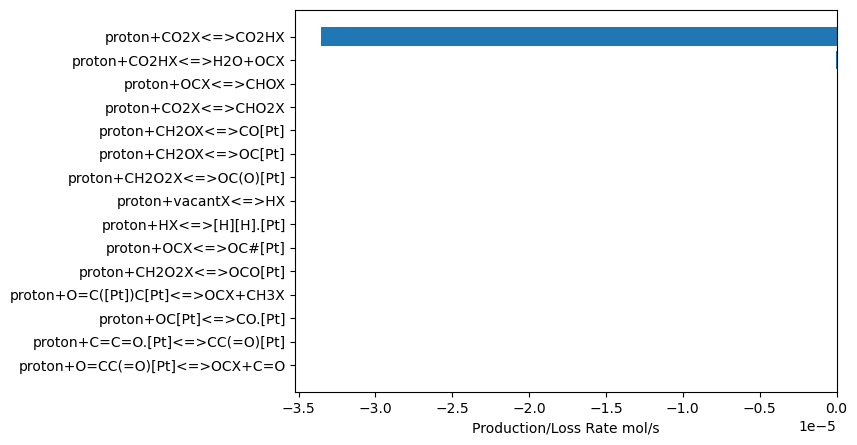

In [95]:
plotROP(ssys, "proton",sol.t[end];N=15,tol=0.0)

Net ROPs for species H2 is: 6.193108809039291e-17
Showing the reaction with 1 th highest ROP for species H2:
vacantX+vacantX+H2<=>HX+HX
ROP = 4.862854583058558e-17
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 2.2394471439851804e9
  n: Float64 0.5000000000000558
  Ea: Float64 88008.54855904997
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species H2:
vacantX+H2<=>[H][H].[Pt]
ROP = 1.330254225965087e-17
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 8934.4204318356
  n: Float64 0.49999999999996914
  Ea: Float64 10385.9426016104
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species H2:
HX+proton<=>H2+vacantX
ROP = 1.5644851400727583e-28
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 96485.0
  q: Float64 0.25
  V0: Float64 0.0
  unc: EmptyRateUncertainty

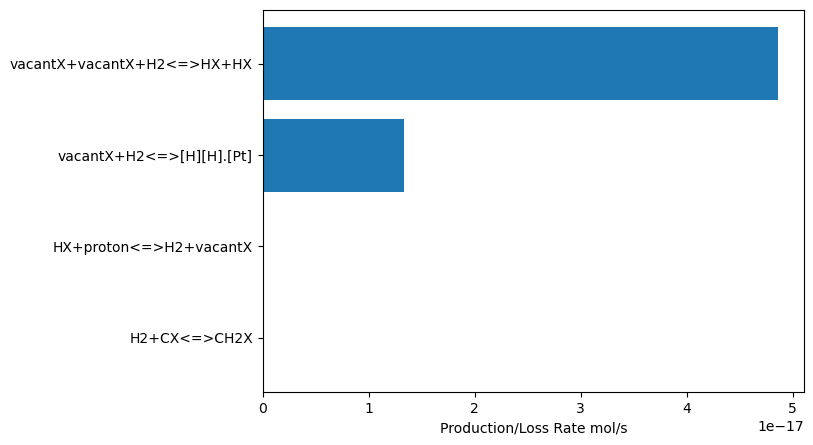

In [96]:
plotROP(ssys, "H2",sol.t[end];N=15,tol=0.0)

Net ROPs for species OCX is: 2.202162356028907e-8
Showing the reaction with 1 th highest ROP for species OCX:
proton+CO2HX<=>H2O+OCX
ROP = 2.386524368354331e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 24121.25
  q: Float64 0.36
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species OCX:
proton+OCX<=>CHOX
ROP = -1.8431611907427894e-9
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 43418.25
  q: Float64 0.49
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species OCX:
vacantX+COC(=O)[Pt]<=>OCX+CO[Pt]
ROP = -4.818823728721895e-13
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 1.46e20
  n: Float64 -0.213
  Ea: Float64 108408.38075667131
  unc: EmptyRateUncertaint

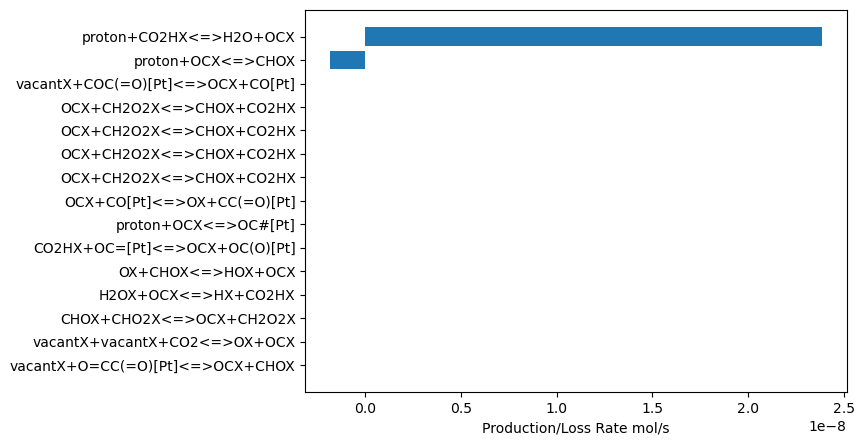

In [97]:
plotROP(ssys, "OCX",sol.t[end];N=15,tol=0.0)

Net ROPs for species O=CO is: 2.087681000668355e-6
Showing the reaction with 1 th highest ROP for species O=CO:
vacantX+O=CO<=>CH2O2X
ROP = 2.0876810006683548e-6
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 23373.5545874235
  n: Float64 0.49999999999977207
  Ea: Float64 1.418358411610997e-9
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species O=CO:
HX+O=CO<=>OC(O)[Pt]
ROP = 3.144490067691637e-22
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 11686.777293693782
  n: Float64 0.49999999999996975
  Ea: Float64 73060.00000000019
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species O=CO:
vacantX+vacantX+O=CO<=>HX+CO2HX
ROP = 1.0801402725838054e-22
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 1.0188995025013999e9
  n: Float64 0.4999999999999998
  Ea: Float64 136711.0572887129
  unc: EmptyRateUncertainty Empty

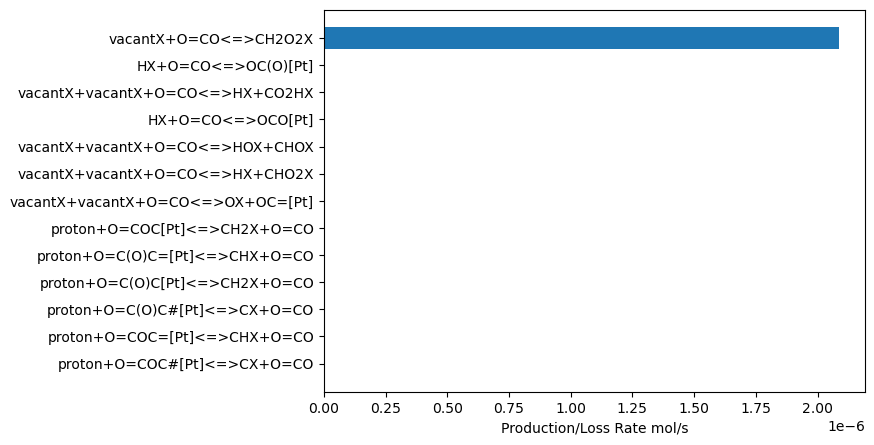

In [98]:
plotROP(ssys, "O=CO",sol.t[end];N=15,tol=0.0)

Net ROPs for species CH2O2X is: 1.4663515387884293e-5
Showing the reaction with 1 th highest ROP for species CH2O2X:
CO2HX+CO2HX<=>CO2X+CH2O2X
ROP = 1.6751171613833454e-5
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 4.18e17
  n: Float64 0.0
  Ea: Float64 64984.89719971026
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species CH2O2X:
vacantX+O=CO<=>CH2O2X
ROP = -2.0876810006683548e-6
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 23373.5545874235
  n: Float64 0.49999999999977207
  Ea: Float64 1.418358411610997e-9
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species CH2O2X:
CHO2X+CO2HX<=>CO2X+CH2O2X
ROP = 6.185476727306986e-12
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 4.18e17
  n: Float64 0.0
  Ea: Float64 26227.25171408696
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 4

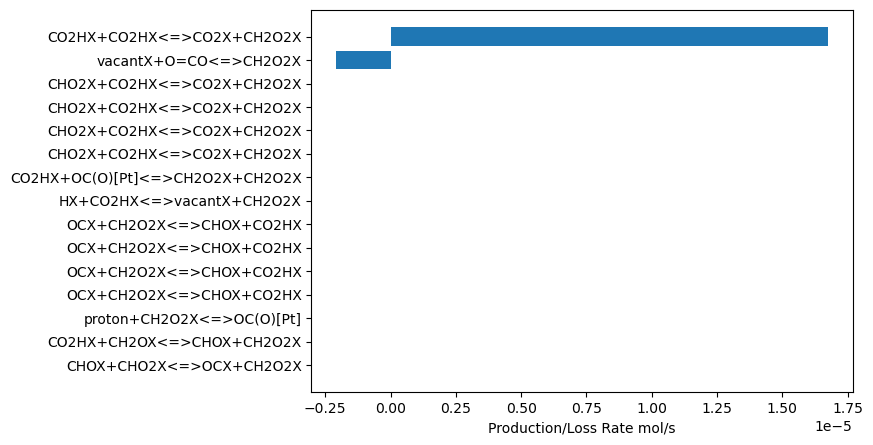

In [99]:
plotROP(ssys,"CH2O2X",sol.t[end];N=15,tol=0.0)

Net ROPs for species CHO2X is: -2.6162170174074386e-20
Showing the reaction with 1 th highest ROP for species CHO2X:
proton+CO2X<=>CHO2X
ROP = 2.4560244053091824e-11
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e14
  n: Float64 0.0
  Ea: Float64 120606.25
  q: Float64 0.46
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species CHO2X:
CHO2X+CO2HX<=>CO2X+CH2O2X
ROP = -6.185476727306986e-12
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 4.18e17
  n: Float64 0.0
  Ea: Float64 26227.25171408696
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species CHO2X:
CHO2X+CO2HX<=>CO2X+CH2O2X
ROP = -6.185476727306986e-12
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 4.18e17
  n: Float64 0.0
  Ea: Float64 26227.25171408696
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the

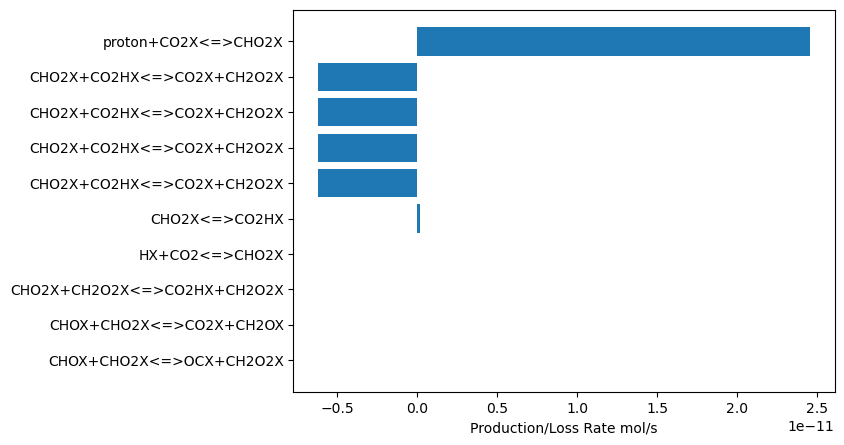

In [100]:
plotROP(ssys,"CHO2X",sol.t[end];N=10,tol=0.0)

Net ROPs for species CO2HX is: -1.5506998596115104e-11
Showing the reaction with 1 th highest ROP for species CO2HX:
proton+CO2X<=>CO2HX
ROP = 3.3526266453156255e-5
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 72363.75
  q: Float64 0.62
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species CO2HX:
CO2HX+CO2HX<=>CO2X+CH2O2X
ROP = -3.350234322766691e-5
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 4.18e17
  n: Float64 0.0
  Ea: Float64 64984.89719971026
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species CO2HX:
proton+CO2HX<=>H2O+OCX
ROP = -2.386524368354331e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 24121.25
  q: Float64 0.36
  V0: Float64 0.0
  unc: EmptyRateUncertain

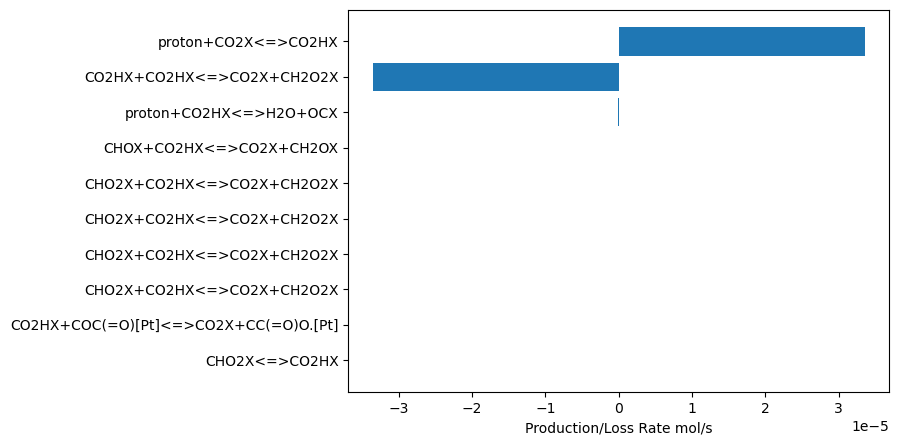

In [101]:
plotROP(ssys,"CO2HX",sol.t[end];N=10,tol=0.0)

Net ROPs for species OCX is: 2.2021600610427646e-8
Showing the reaction with 1 th highest ROP for species OCX:
proton+CO2HX<=>H2O+OCX
ROP = 2.386524368354331e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 24121.25
  q: Float64 0.36
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species OCX:
proton+OCX<=>CHOX
ROP = -1.8431611907427894e-9
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.5e10
  n: Float64 0.0
  Ea: Float64 43418.25
  q: Float64 0.49
  V0: Float64 0.0
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species OCX:
vacantX+COC(=O)[Pt]<=>OCX+CO[Pt]
ROP = -4.818823728721895e-13
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 1.46e20
  n: Float64 -0.213
  Ea: Float64 108408.38075667131
  unc: EmptyRateUncertain

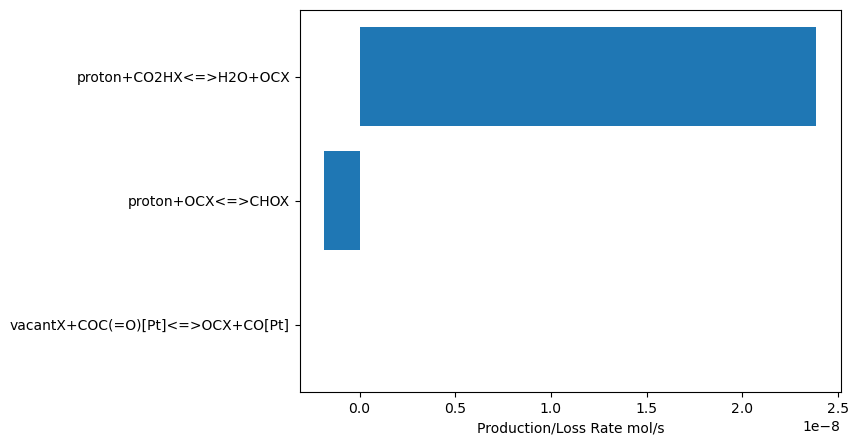

In [102]:
plotROP(ssys,"OCX",sol.t[end])